In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectPercentile, mutual_info_classif

nltk.download('stopwords')
nltk.download('punkt')

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
df = pd.read_csv("/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/train.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [ ]:
df.head(5)

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [ ]:
def CaseFoldingTeks(teks):
    return teks.lower()

def tokenizingTeks(teks):
    return word_tokenize(teks)

def filteringTeks(teks):
    listStopWords = set(stopwords.words("english"))
    filtered = []
    for tks in teks:
        if tks not in listStopWords:
            filtered.append(tks)
    teks = filtered
    return teks

In [ ]:
df["Title"] = df["Title"].apply(CaseFoldingTeks)
df["Description"] = df["Description"].apply(CaseFoldingTeks)
df["Title"] = df["Title"].apply(tokenizingTeks)
df["Description"] = df["Description"].apply(tokenizingTeks)
df["Title"] = df["Title"].apply(filteringTeks)
df["Description"] = df["Description"].apply(filteringTeks)

In [ ]:
df = df[df["Class Index"] != 3].reset_index(drop=True)

print("Daftar label yang tersisa:")
print(df["Class Index"].value_counts())

Daftar label yang tersisa:
Class Index
4    30000
2    30000
1    30000
Name: count, dtype: int64


In [ ]:
X = df["Title"].fillna("").astype(str) + " " + df["Description"].fillna("").astype(str)
y = df["Class Index"]

In [ ]:
vectorizer = TfidfVectorizer()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
ig_selector = SelectPercentile(score_func=mutual_info_classif, percentile=10)
X_train_selected = ig_selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = ig_selector.transform(X_test_tfidf)

print(f"Jumlah kata sebelum seleksi: {X_train_tfidf.shape[1]}")
print(f"Jumlah kata setelah seleksi 10%: {X_train_selected.shape[1]}")

Jumlah kata sebelum seleksi: 53762
Jumlah kata setelah seleksi 10%: 5377


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42, splitter='best', criterion='entropy', ccp_alpha=0.0001)
model.fit(X_train_selected, y_train)

DecisionTreeClassifier(ccp_alpha=0.0001, criterion='entropy', random_state=42)

In [ ]:
akurasi = model.score(X_test_selected, y_test)
print(f"Akurasi Model : {akurasi * 100:.2f}%")

Akurasi Model : 87.85%


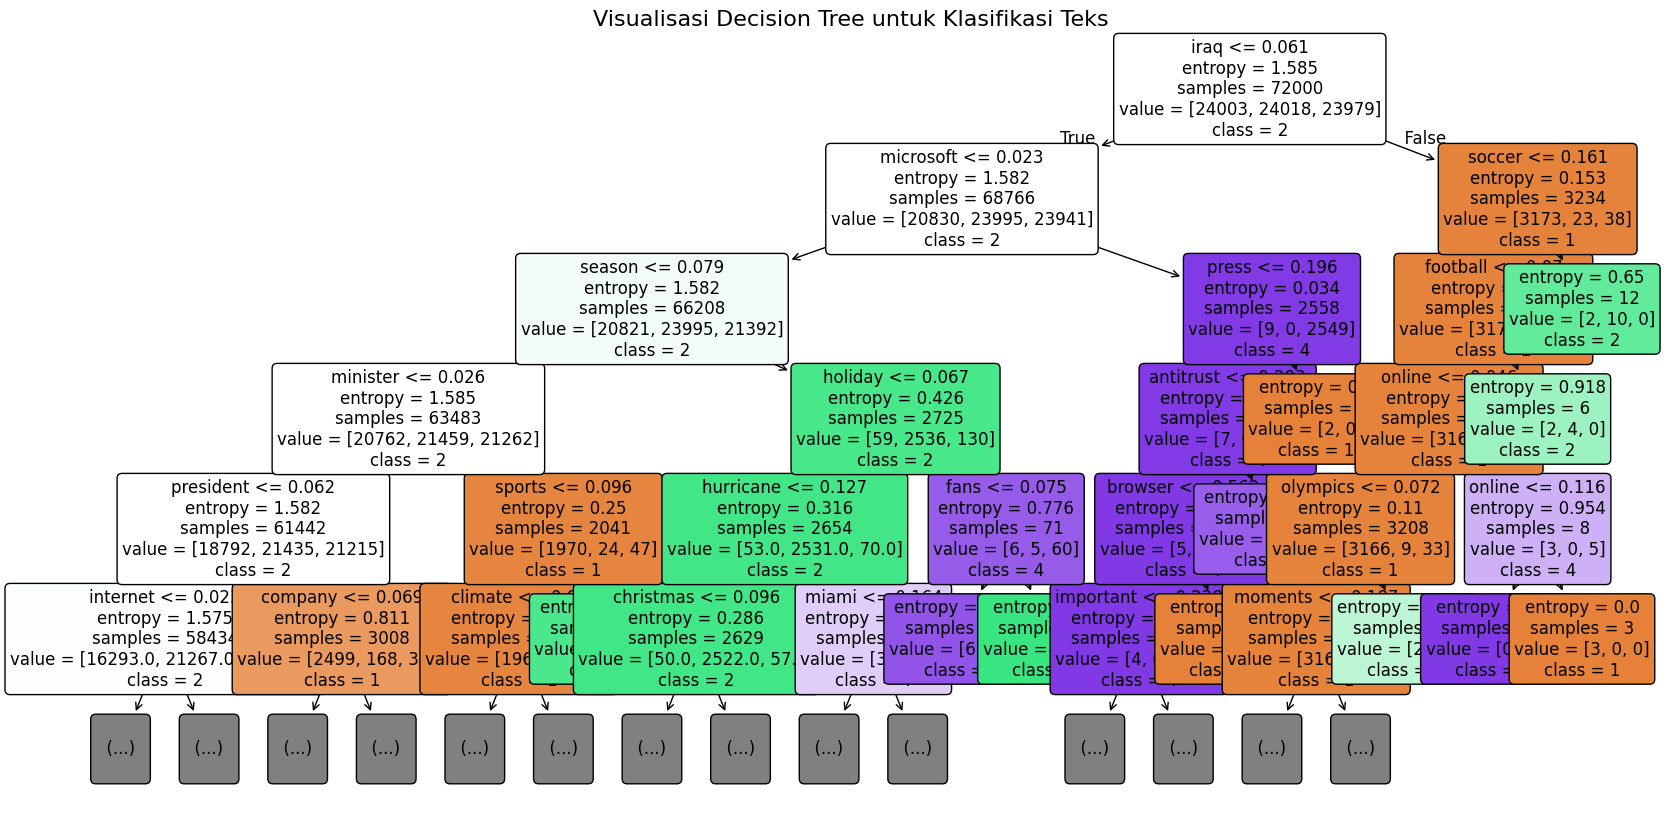

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

nama_fitur_asli = vectorizer.get_feature_names_out()
nama_fitur_terpilih = nama_fitur_asli[ig_selector.get_support()]

nama_kelas_teks = [str(kelas) for kelas in model.classes_]

plot_tree(model,
          feature_names=nama_fitur_terpilih,
          class_names=nama_kelas_teks,
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=5)

plt.title("Visualisasi Decision Tree untuk Klasifikasi Teks", fontsize=16)

plt.savefig("pohon_klasifikasi.png", dpi=300, bbox_inches='tight')

plt.show()

# Cek overfitting

In [ ]:
from sklearn.model_selection import cross_validate
import numpy as np

model = DecisionTreeClassifier(random_state=42, splitter='best', criterion='entropy', max_depth=150, ccp_alpha=0.0001)

hasil_cv = cross_validate(model, X_train_selected, y_train, cv=5, return_train_score=True)

skor_training = hasil_cv['train_score']
skor_testing = hasil_cv['test_score']

print(f"Skor Training (5 Ronde): {np.round(skor_training * 100, 2)}")
print(f"Skor Testing  (5 Ronde): {np.round(skor_testing * 100, 2)}\n")

print(f"Rata-rata Akurasi Training : {skor_training.mean() * 100:.2f}%")
print(f"Rata-rata Akurasi Testing  : {skor_testing.mean() * 100:.2f}%")

Skor Training (5 Ronde): [92.85 93.02 93.07 93.12 93.09]
Skor Testing  (5 Ronde): [85.93 85.28 85.17 86.34 86.15]

Rata-rata Akurasi Training : 93.03%
Rata-rata Akurasi Testing  : 85.78%


Melatih model utama dengan 100% data training...
Model berhasil dilatih!

=== HASIL EVALUASI DATA TEST KAGGLE ===
Dimensi Data Test : (5700, 5377)
Akurasi Model     : 85.25%

Detail Laporan Klasifikasi:
              precision    recall  f1-score   support

           1       0.88      0.80      0.84      1900
           2       0.91      0.85      0.88      1900
           4       0.79      0.91      0.84      1900

    accuracy                           0.85      5700
   macro avg       0.86      0.85      0.85      5700
weighted avg       0.86      0.85      0.85      5700

Menampilkan Confusion Matrix...


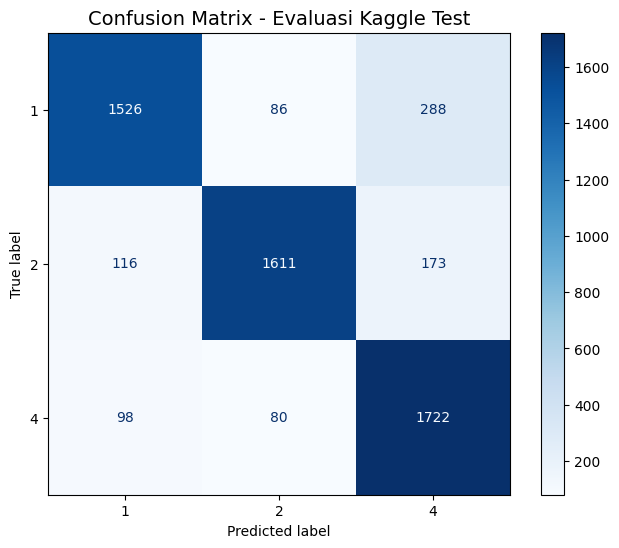

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Melatih model utama dengan 100% data training...")
model.fit(X_train_selected, y_train)
print("Model berhasil dilatih!\n")

df_test_kaggle = pd.read_csv('/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/test.csv')

df_test_kaggle = df_test_kaggle[df_test_kaggle["Class Index"] != 3]
df_test_kaggle = df_test_kaggle.reset_index(drop=True)

X_test_baru = df_test_kaggle["Title"].fillna("").astype(str) + " " + df_test_kaggle["Description"].fillna("").astype(str)
y_test_baru = df_test_kaggle["Class Index"]

X_test_baru_tfidf = vectorizer.transform(X_test_baru)

X_test_baru_selected = ig_selector.transform(X_test_baru_tfidf)

y_prediksi = model.predict(X_test_baru_selected)

akurasi = accuracy_score(y_test_baru, y_prediksi)

print("=== HASIL EVALUASI DATA TEST KAGGLE ===")
print(f"Dimensi Data Test : {X_test_baru_selected.shape}")
print(f"Akurasi Model     : {akurasi * 100:.2f}%\n")

print("Detail Laporan Klasifikasi:")
print(classification_report(y_test_baru, y_prediksi))

print("Menampilkan Confusion Matrix...")

cm = confusion_matrix(y_test_baru, y_prediksi)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Confusion Matrix - Evaluasi Kaggle Test", fontsize=14)
plt.show()

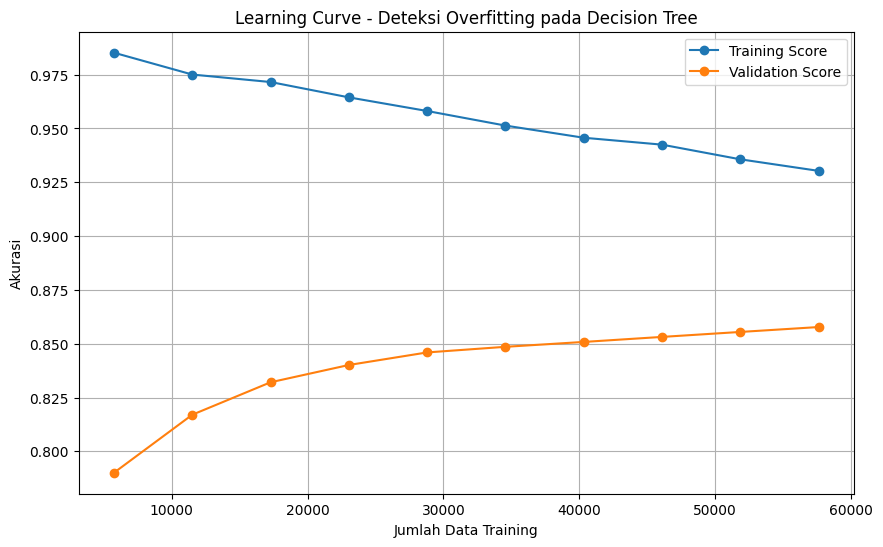

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_selected, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score', marker='o')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Score', marker='o')
plt.title('Learning Curve - Deteksi Overfitting pada Decision Tree')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.show()

# mencari titik optimal

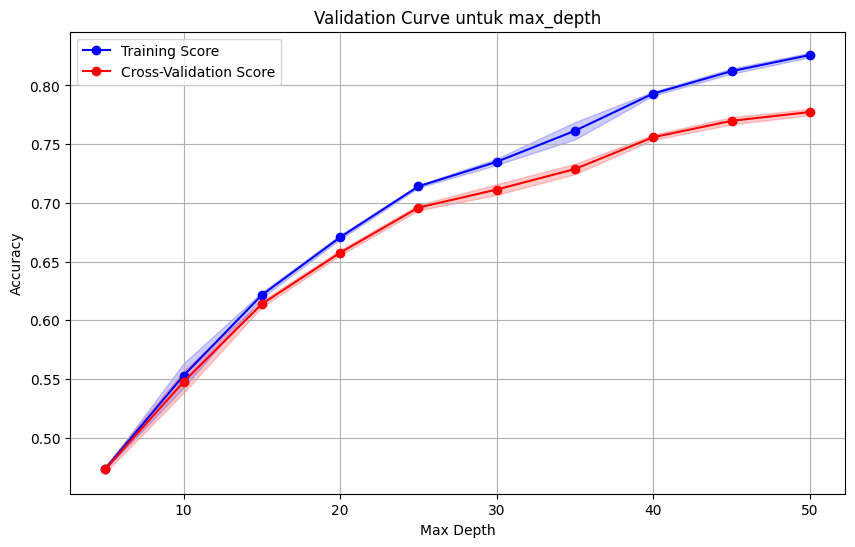

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.tree import DecisionTreeClassifier


param_range = np.arange(5, 55, 5)

train_scores, test_scores = validation_curve(
    estimator=DecisionTreeClassifier(random_state=42, criterion='entropy'),
    X=X_train_selected,
    y=y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Validation Curve untuk max_depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")

plt.plot(param_range, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")

plt.plot(param_range, test_mean, label="Cross-Validation Score", color="red", marker="o")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="red")

plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Definisikan model dasar
# Kita tidak perlu mendefinisikan max_depth atau ccp_alpha di sini,
# karena akan diatur oleh GridSearchCV
base_model = DecisionTreeClassifier(
    random_state=42,
    criterion='entropy',
    splitter='best'
)

# 2. Definisikan grid parameter yang ingin diuji
# Sesuaikan rentang nilai ini jika komputasi terlalu lama atau terlalu cepat
param_grid = {
    'max_leaf_nodes': [None, 20, 50, 100, 200, 500], # None artinya tidak dibatasi
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01, 0.05, 0.1] # Nilai pruning
}

# 3. Setup GridSearchCV
# cv=5: 5-fold cross validation
# n_jobs=-1: Menggunakan semua core CPU agar proses pencarian lebih cepat
# verbose=1: Menampilkan progress bar agar kita tahu prosesnya sedang berjalan
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Jalankan pencarian parameter
print("🔍 Mencari parameter optimal (ini mungkin memakan waktu 1-3 menit)...")
grid_search.fit(X_train_selected, y_train)

# 5. Tampilkan hasil terbaik
print("\n" + "="*50)
print("✅ HASIL PENCARIAN PARAMETER OPTIMAL")
print("="*50)
print(f"Kombinasi Parameter Terbaik : {grid_search.best_params_}")
print(f"Rata-rata Akurasi CV (5-Fold): {grid_search.best_score_ * 100:.2f}%")
print("="*50)

# 6. Evaluasi model TERBAIK ini ke Data Test Kaggle
best_model = grid_search.best_estimator_
y_pred_optimal = best_model.predict(X_test_baru_selected)

print("\n📊 EVALUASI MODEL TERBAIK PADA DATA TEST")
print(f"Dimensi Data Test : {X_test_baru_selected.shape}")
print(f"Akurasi Test      : {accuracy_score(y_test_baru, y_pred_optimal) * 100:.2f}%\n")
print("Detail Laporan Klasifikasi:")
print(classification_report(y_test_baru, y_pred_optimal))

🔍 Mencari parameter optimal (ini mungkin memakan waktu 1-3 menit)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ HASIL PENCARIAN PARAMETER OPTIMAL
Kombinasi Parameter Terbaik : {'ccp_alpha': 0.0, 'max_leaf_nodes': None}
Rata-rata Akurasi CV (5-Fold): 86.66%

📊 EVALUASI MODEL TERBAIK PADA DATA TEST
Dimensi Data Test : (5700, 5377)
Akurasi Test      : 85.18%

Detail Laporan Klasifikasi:
              precision    recall  f1-score   support

           1       0.81      0.83      0.82      1900
           2       0.90      0.87      0.89      1900
           4       0.84      0.85      0.85      1900

    accuracy                           0.85      5700
   macro avg       0.85      0.85      0.85      5700
weighted avg       0.85      0.85      0.85      5700



In [ ]:
# Misalkan dari grafik kamu menemukan max_depth terbaik adalah 15
best_max_depth = 40

print(f"Melatih ulang model dengan max_depth={best_max_depth}...")
model_optimal = DecisionTreeClassifier(
    random_state=42,
    splitter='best',
    criterion='entropy',
    max_depth=best_max_depth,
    max_leaf_nodes = None,
    ccp_alpha = 0
)
model_optimal.fit(X_train_selected, y_train)
print("Model berhasil dilatih ulang!")

Melatih ulang model dengan max_depth=40...
Model berhasil dilatih ulang!


In [ ]:
from sklearn.model_selection import cross_validate
import numpy as np

print(f"Mengecek performa model optimal (max_depth={best_max_depth}) dengan 5-Fold Cross Validation...")

# Lakukan cross validation pada model yang sudah dioptimalkan
hasil_cv_optimal = cross_validate(
    model_optimal,
    X_train_selected,
    y_train,
    cv=5,
    return_train_score=True,
    n_jobs=-1 # Menggunakan semua core CPU agar proses lebih cepat
)

skor_training_opt = hasil_cv_optimal['train_score']
skor_testing_opt = hasil_cv_optimal['test_score']

print(f"Skor Training (5 Fold): {np.round(skor_training_opt * 100, 2)}")
print(f"Skor Testing  (5 Fold): {np.round(skor_testing_opt * 100, 2)}")
print("-" * 50)
print(f"Rata-rata Akurasi Training : {skor_training_opt.mean() * 100:.2f}%")
print(f"Rata-rata Akurasi Testing  : {skor_testing_opt.mean() * 100:.2f}%")
print(f"Selisih (Gap) Akurasi      : {(skor_training_opt.mean() - skor_testing_opt.mean()) * 100:.2f}%")

# Evaluasi sederhana apakah overfitting berkurang
gap_sebelumnya = 93.03 - 85.78 # Dari output notebook kamu sebelumnya
gap_sekarang = (skor_training_opt.mean() - skor_testing_opt.mean()) * 100

if gap_sekarang < gap_sebelumnya:
    print("\n✅ KESIMPULAN: Gap antara training dan testing MENGECEL. Model lebih stabil dan overfitting berkurang!")
else:
    print("\n⚠️ KESIMPULAN: Gap masih besar atau membesar. Pertimbangkan untuk menurunkan max_depth atau meningkatkan ccp_alpha.")

Mengecek performa model optimal (max_depth=40) dengan 5-Fold Cross Validation...
Skor Training (5 Fold): [79.23 79.53 79.48 79.15 79.14]
Skor Testing  (5 Fold): [75.58 75.27 75.64 75.51 75.96]
--------------------------------------------------
Rata-rata Akurasi Training : 79.31%
Rata-rata Akurasi Testing  : 75.59%
Selisih (Gap) Akurasi      : 3.72%

✅ KESIMPULAN: Gap antara training dan testing MENGECEL. Model lebih stabil dan overfitting berkurang!


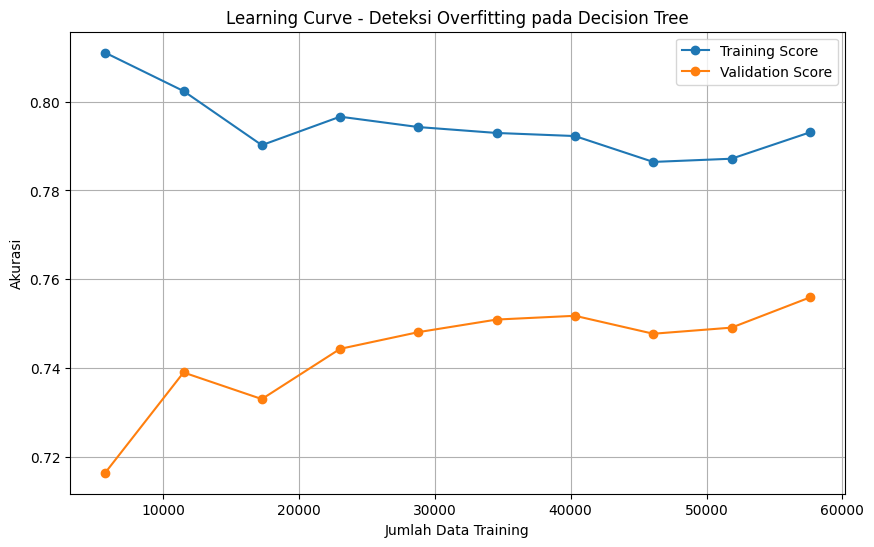

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    model_optimal, X_train_selected, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score', marker='o')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Score', marker='o')
plt.title('Learning Curve - Deteksi Overfitting pada Decision Tree')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import joblib

# Simpan vectorizer, feature selector, dan model
joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(ig_selector, 'selector.pkl')
joblib.dump(model_optimal, 'model.pkl')

print("Model dan preprocessor berhasil disimpan!")